In [ ]:
!pip install roboflow ultralytics

# YOLO for Image segmentation

## Problem Definition

- Task: Image Segmentation
- Objective: Predict pixel-level masks for objects (not just boxes)

- Type: Instance Segmentation (YOLO)<br>
        Output = masks + boxes

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import yaml
from collections import Counter
import glob


from roboflow import Roboflow

from ultralytics import YOLO

from google.colab import userdata
from kaggle_secrets import UserSecretsClient

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset + EDA

In [3]:
# rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
# rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
rf = Roboflow(api_key=UserSecretsClient().get_secret('ROBOFLOW_API_KEY'))

project = rf.workspace("chetan-sharma-n4cau").project("yolo-fine_tuned")
dataset = project.version(1).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to YOLO-fine_tuned-1 in yolo26:: 100%|██████████| 352/352 [00:00<00:00, 6069.56it/s]


In [8]:
data_path = './YOLO-fine_tuned-1/'
train_path = f'{data_path}/train/'
val_path = f'{data_path}/valid/'
test_path = f'{data_path}/test/'

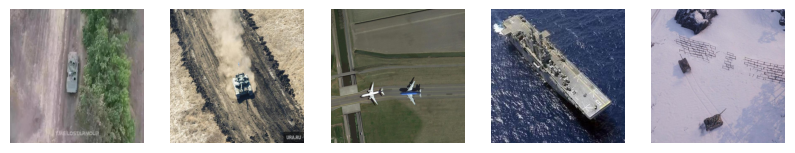

In [ ]:
def show_samples(image_dir, n=5):
    imgs = os.listdir(image_dir)

    plt.figure(figsize=(10,5))

    for i in range(n):
        img_name = random.choice(imgs)
        img_path = os.path.join(image_dir, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

show_samples(f"{train_path}/images")

In [9]:
with open(f'{data_path}data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
num_classes = data_config['nc']

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Number of classes: 3
Class names: ['Aircraft', 'Aircraft carrier', 'Tank']


In [17]:
def count_files(directory):
    return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])

train_images = count_files(os.path.join(train_path, 'images'))
train_labels = count_files(os.path.join(train_path, 'labels'))
val_images = count_files(os.path.join(val_path, 'images'))
val_labels = count_files(os.path.join(val_path, 'labels'))
test_images = count_files(os.path.join(test_path, 'images'))
test_labels = count_files(os.path.join(test_path, 'labels'))

print(f"Training set: {train_images} images, {train_labels} labels")
print(f"Validation set: {val_images} images, {val_labels} labels")
print(f"Test set: {test_images} images, {test_labels} labels")

Training set: 85 images, 85 labels
Validation set: 43 images, 43 labels
Test set: 42 images, 42 labels


In [11]:
label_files = glob.glob(f'{train_path}/labels/*.txt')

class_counts = Counter()

for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f:
            class_id = int(line.split(' ')[0])
            class_counts[class_id] += 1

# Map class IDs to class names
class_distribution = {class_names[k]: v for k, v in class_counts.items()}

print("Class Distribution in Training Set:")
for class_name, count in class_distribution.items():
    print(f"{class_name}: {count}")

Class Distribution in Training Set:
Tank: 114
Aircraft carrier: 32
Aircraft: 108


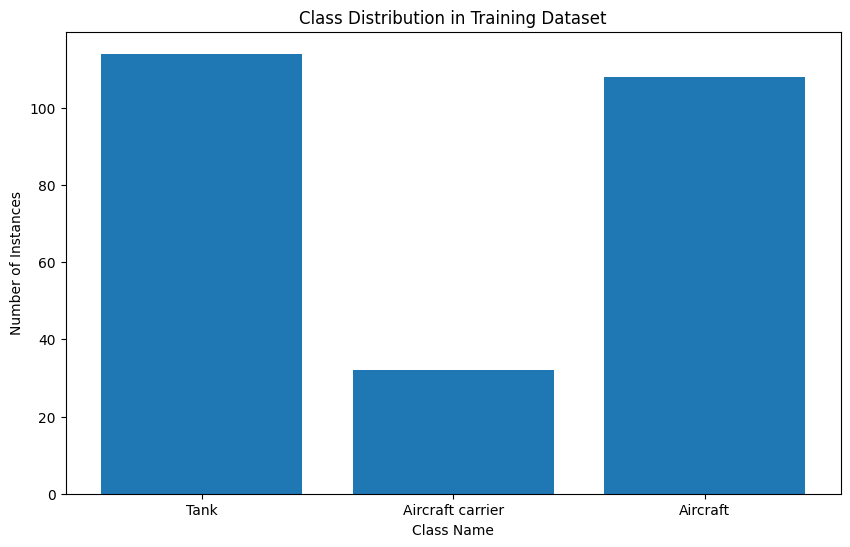

In [16]:
import matplotlib.pyplot as plt

classes = list(class_distribution.keys())
counts = list(class_distribution.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, counts)
plt.xlabel('Class Name')
plt.ylabel('Number of Instances')
plt.title('Class Distribution in Training Dataset')
plt.show()

### EDA Findings

*   **Dataset Size:** The dataset is relatively small, with 85 images in the training set, 43 in the validation set, and 42 in the test set.
*   **Class Imbalance:** There is an imbalance in the class distribution within the training set. 'Aircraft carrier' has significantly fewer instances (32) compared to 'Tank' (114) and 'Aircraft' (108).
*   **Object Types:** The dataset contains images with three distinct object types: Aircraft, Aircraft carrier, and Tank, for which segmentation masks are to be predicted.

## Preprocessing + Augmentation
- auto scaling done in robo flow
- images are resized to 640*640 in roboflow

## Model + Config
- Model: Ultralytics YOLO (YOLOv11 Classification)
- Uses pretrained CNN backbone for fast and efficient feature extraction
- Simple training pipeline with built-in augmentation and evaluation
- Provides good speed–accuracy tradeoff for quick image classification tasks

In [ ]:
model = YOLO("yolo11n-seg.pt")

## Model Training

In [ ]:
results = model.train(
    data=f"{data_path}data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    workers=4
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/YOLO-fine_tuned-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

## Evaluation & Visualization

Text(0.5, 1.0, 'Training Curves')

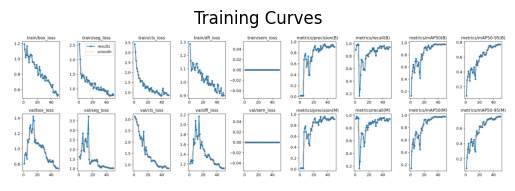

In [ ]:
img = plt.imread("/kaggle/working/runs/segment/train2/results.png")
plt.imshow(img)
plt.axis("off")
plt.title("Training Curves")

In [ ]:
metrics = model.val()
# print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1464.9±460.1 MB/s, size: 66.6 KB)
val: Scanning /kaggle/working/YOLO-fine_tuned-1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.7s1.8s
                   all         43        107      0.943      0.915      0.975      0.779      0.943      0.915       0.98       0.75
              Aircraft         13         52      0.952      0.962      0.984      0.907      0.952      0.962      0.984      0.751
      Aircraft carrier         16         16      0.917      0.938      0.988      0.754      0.917      0.938      0.988      0.763
                  Tank         14         39      0.959      0.846      0.954      0.676      0.959      0.846     

In [ ]:
metrics.confusion_matrix.plot(save_dir=".")

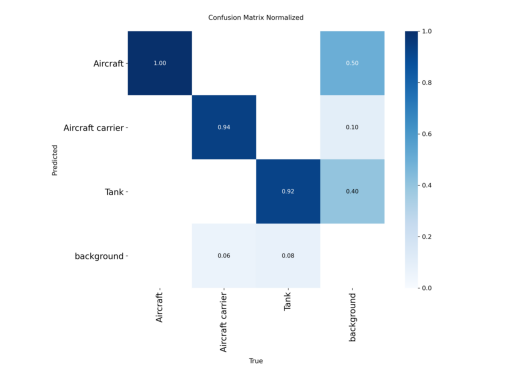

In [ ]:
img = cv2.imread('confusion_matrix_normalized.png')

if img is not None:
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

### Inference

In [ ]:
results = model.predict(
    source=f"{test_path}/images",
    conf=0.5
)


image 1/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0019_jpg.rf.9cbb569b90a5f7fc1121577c22f8f7d8.jpg: 640x640 14 Aircrafts, 11.0ms
image 2/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0029_jpg.rf.4754ee2ec3bebe3ebb56a7cadd69fa87.jpg: 640x640 3 Aircrafts, 10.6ms
image 3/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0031_jpg.rf.744c91cf97b12567e5ab5e790a284f05.jpg: 640x640 2 Aircrafts, 10.7ms
image 4/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0034_jpg.rf.f89f9eec0dec89499606be2d92cb128b.jpg: 640x640 1 Aircraft, 11.5ms
image 5/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0036_jpg.rf.ad39a524b9be26f9ea10c64b56600d96.jpg: 640x640 2 Aircrafts, 11.0ms
image 6/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0038_jpg.rf.41f79a3db126a855cc305cbae2d0865c.jpg: 640x640 2 Aircrafts, 10.9ms
image 7/42 /kaggle/working/YOLO-fine_tuned-1/test/images/0042_jpg.rf.780e00b16e0c3cbcc009ca0f0b968865.jpg: 640x640 1 Aircraft, 10.8ms
image 8/42 /kaggle/working/YOLO-fine_tuned-1/test/image

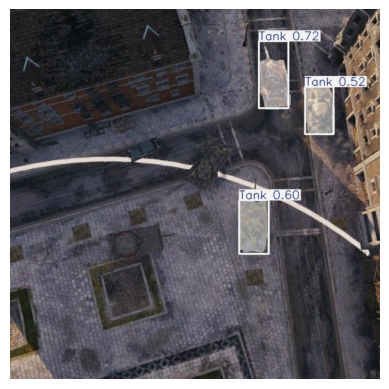

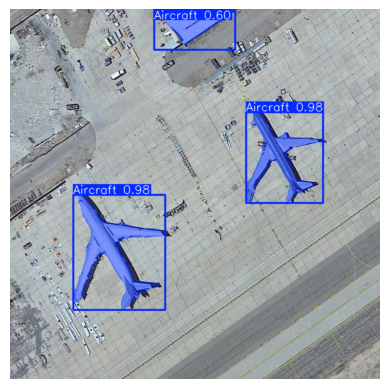

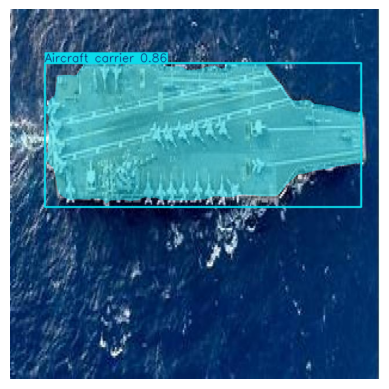

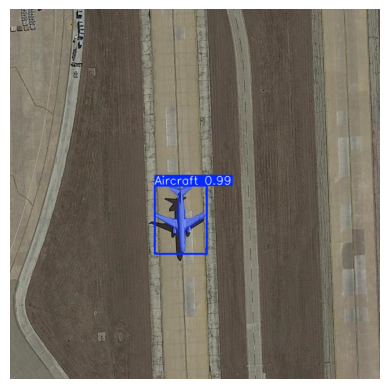

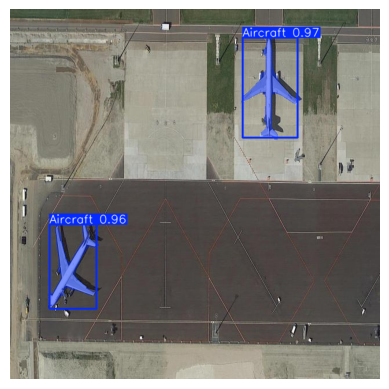

In [ ]:
n = min(5, len(results))
samples = random.sample(results, n)

for r in samples:
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

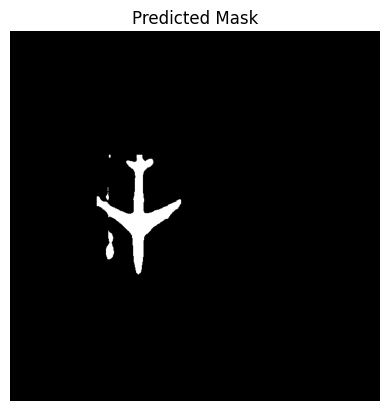

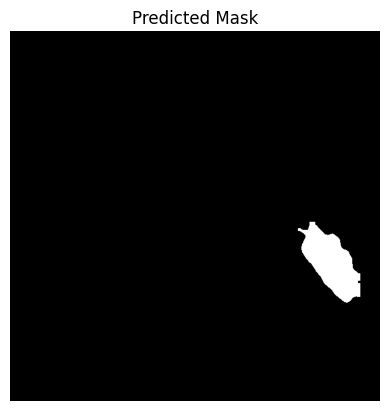

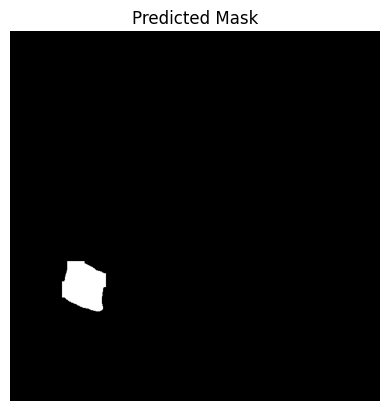

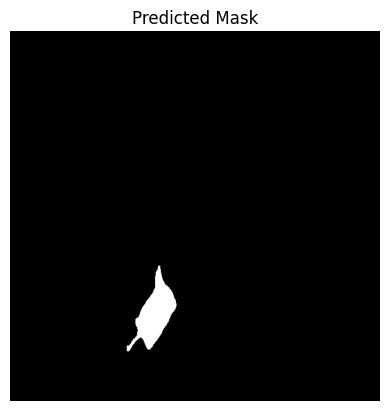

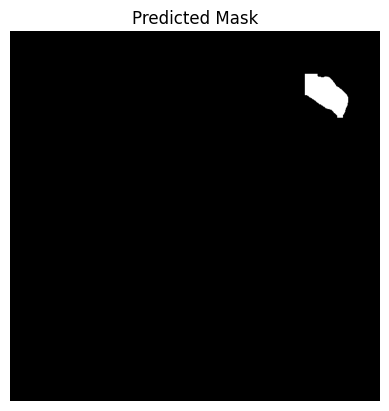

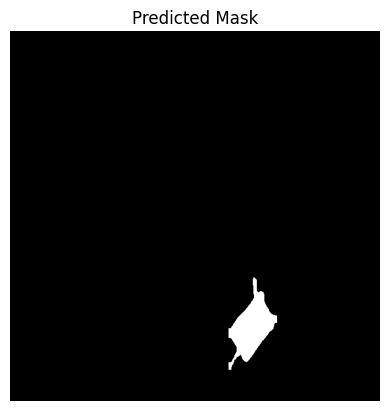

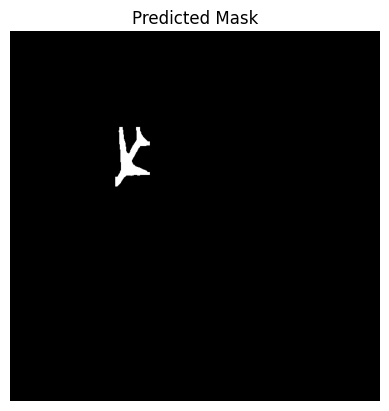

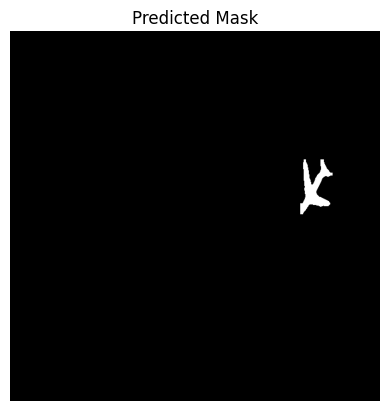

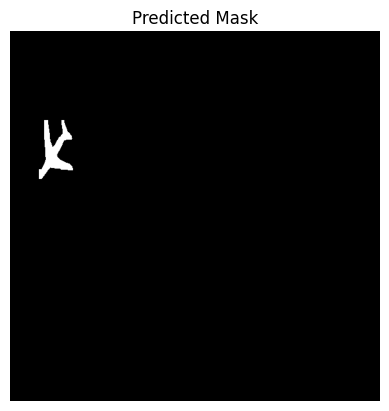

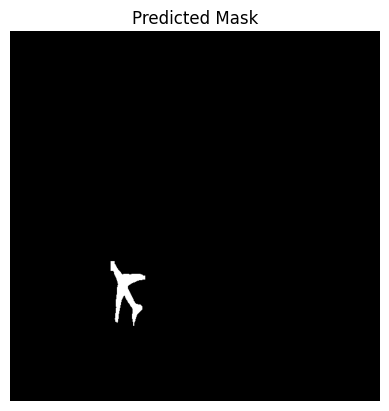

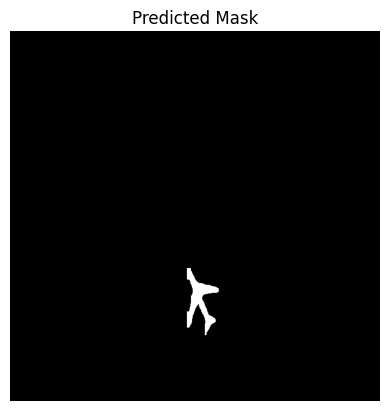

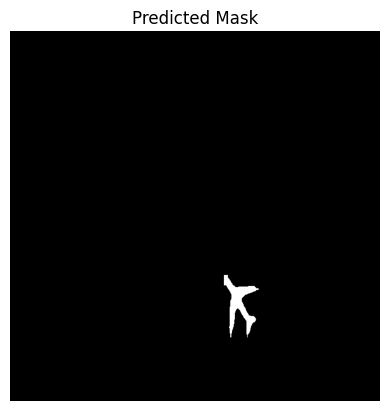

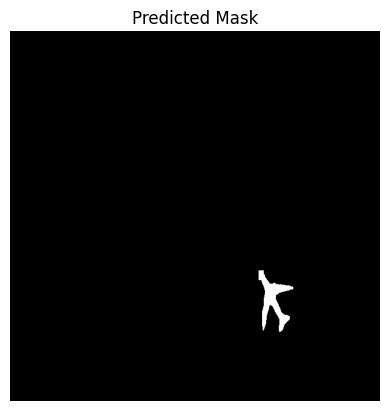

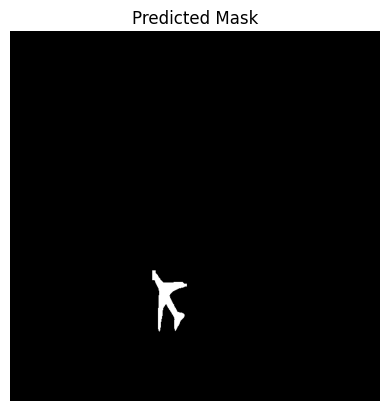

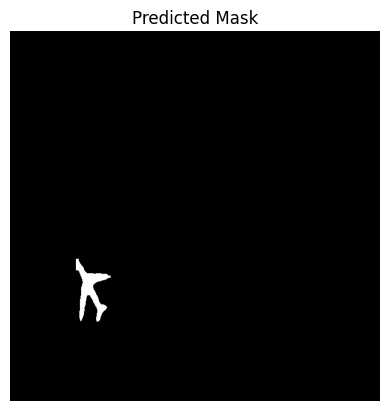

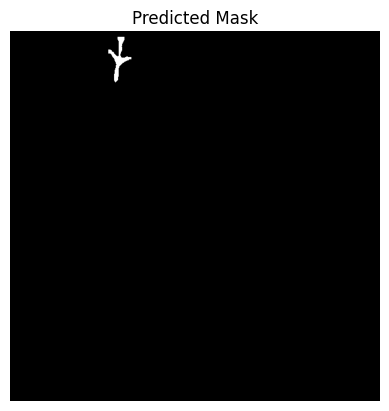

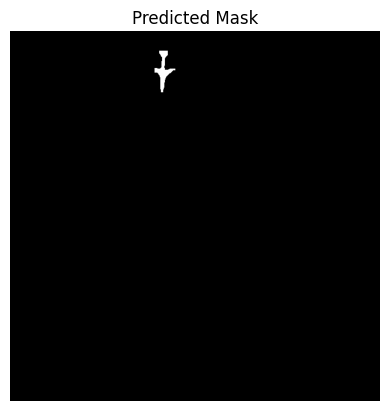

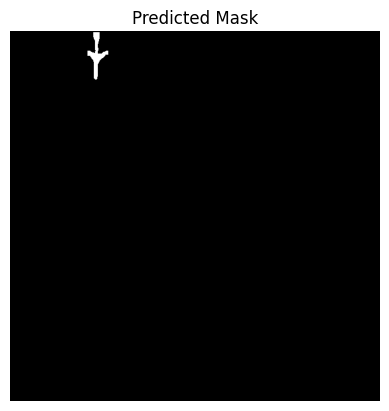

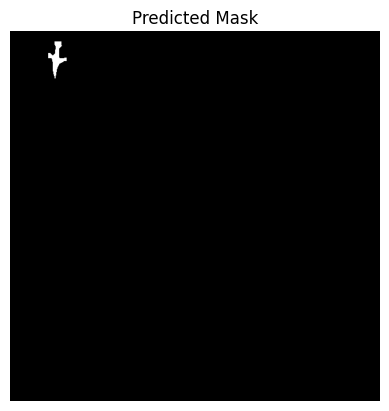

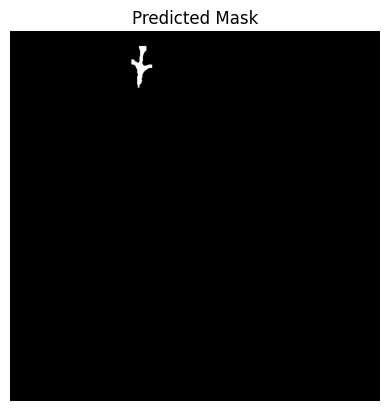

In [ ]:
n = min(3, len(results))
samples = random.sample(results, n)

for r in samples:
    if r.masks is not None:  # safety check

        masks = r.masks.data.cpu().numpy()

        for mask in masks:
            plt.imshow(mask, cmap='gray')
            plt.title("Predicted Mask")
            plt.axis("off")
            plt.show()

### Save best model

In [ ]:
model = YOLO("/kaggle/working/runs/segment/train2/weights/best.pt")

In [ ]:
model.export(format="onnx")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n-seg summary (fused): 114 layers, 2,835,153 parameters, 0 gradients, 9.6 GFLOPs

PyTorch: starting from '/kaggle/working/runs/segment/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 39, 8400), (1, 32, 160, 160)) (5.7 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.6s, saved as '/kaggle/working/runs/segment/train2/weights/best.onnx' (11.1 MB)

Export complete (2.0s)
Results saved to /kaggle/working/runs/segment/train2/weights
Predict:         yolo predict task=segment model=/kaggle/working/runs/segment/train2/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/kaggle/working/runs/segment/train2/weights/best.onnx imgsz=640 data=/kaggle/working/YOLO-fine_tuned-1/data.yaml  
Visualize:       https://netron.app


'/kaggle/working/runs/segment/train2/weights/best.onnx'

## Conclusion

*   **Model Used:** An Ultralytics YOLOv11 segmentation model (`yolo11n-seg.pt`) was utilized for instance segmentation on custom dataset.
*   **Training Overview:** The model was trained for 50 epochs with an image size of 640x640 and a batch size of 8. The training included a pre-trained CNN backbone and built-in augmentation.
*   **Evaluation Performance:** On the validation set, the model achieved strong results with an `mAP50-95` of 0.779 for bounding boxes and 0.75 for masks, indicating good segmentation and detection capabilities.
*   **Inference Capabilities:** The trained model was successfully used to predict on the test set images, generating both bounding box detections and segmentation masks for 'Aircraft', 'Aircraft carrier', and 'Tank' objects.